# **FINAL PROJECT DATA ANALYST**

dataset = https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?select=olist_customers_dataset.csv

# **Data Understanding**

Dataset ini diberikan oleh Olist, toko besar di Brazil. Olist membantu usaha kecil di seluruh Brazil untuk menjual produk mereka dengan mudah melalui satu kontrak dan tanpa ribet. Para pedagang ini bisa menjual produk lewat Olist Store dan mengirimkannya langsung ke pelanggan dengan bantuan mitra logistik Olist.

Perusahaan e-commerce, seperti Olist, berkembang dengan menjaga hubungan yang kuat dengan pelanggan dan memaksimalkan nilai dari basis pelanggan mereka. Untuk mencapainya, perusahaan perlu mengidentifikasi pelanggan yang paling berharga, berinteraksi dengan mereka secara efektif, dan mengalokasikan sumber daya secara efisien untuk retensi dan penjualan tambahan (upselling).

Analisis RFM (Recency, Frequency, and Monetary) adalah kerangka kerja yang terbukti efektif untuk mengelompokkan pelanggan berdasarkan perilaku pembelian mereka. Dengan menganalisis RFM, Olist dapat lebih memahami segmen pelanggan mereka, memprioritaskan pelanggan yang memiliki nilai tinggi, dan merancang kampanye pemasaran yang lebih terarah.

Penjelasan tersebut merujuk pada pentingnya menggunakan analisis RFM untuk mengoptimalkan hubungan dengan pelanggan melalui pemahaman tentang perilaku mereka, seperti seberapa baru mereka membeli (Recency), seberapa sering mereka membeli (Frequency), dan seberapa banyak mereka menghabiskan uang (Monetary). Hal ini memungkinkan perusahaan untuk membuat keputusan yang lebih baik dalam mengelola dan memaksimalkan nilai pelanggan.









**Business Questions**
1. Bagaimana distribusi pelanggan berdasarkan nilai Recency, Frequency, dan Monetary?
2. Segmen pelanggan mana yang memiliki nilai Recency, Frequency, dan Monetary tertinggi dan
terendah?
3. Berapa total jumlah pelanggan di setiap segmentasi?
4. Berapa total revenue yang dihasilkan oleh masing-masing segmentasi pelanggan?
5. Siapa saja pelanggan yang termasuk dalam masing-masing segmen RFM?


**Segmentations**
1. Champion (Skor 9)
2. Loyal (Skor 8)
3. Potential Loyalist (Skor 7)
4. Average (Skor 6)
5. Cannot Lose Them (Skor 5)
6. About To Sleep (Skor 4)
7. Lost Customer (Skor 3)

## **Data Overview**

In [351]:
# Import library to be used in the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [352]:
# Load Datasets

customers = pd.read_csv("C:\DIBIMBING\olist_customers_dataset.csv")
orders = pd.read_csv("C:\DIBIMBING\olist_orders_dataset.csv")
items = pd.read_csv("C:\DIBIMBING\olist_order_items_dataset.csv")
products = pd.read_csv("C:\DIBIMBING\olist_products_dataset.csv")
sellers = pd.read_csv("C:\DIBIMBING\olist_sellers_dataset.csv")
translation = pd.read_csv("C:\DIBIMBING\product_category_name_translation.csv")
payment = pd.read_csv("C:\DIBIMBING\olist_order_payments_dataset.csv")

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
C:\Users\mahes\AppData\Local\Temp\ipykernel_6076\3550104436.py:3: SyntaxWarning: invalid escape sequence '\D'
  customers = pd.read_csv("C:\DIBIMBING\olist_customers_dataset.csv")
C:\Users\mahes\AppData\Local\Temp\ipykernel_6076\3550104436.py:4: SyntaxWarning: invalid escape sequence '\D'
  orders =

# **Data Cleaning / Data Manupulation**

**Merge Dataset**

Merge dataset pada data olist_ecommerce dilakukan di awal karena data yang diberikan terpisah pisah, sehingga perlu digabung terlebih dahulu sebelum melakukan cleaning data.

In [353]:
# 1. Merge orders with items
merged_data = pd.merge(orders, items, how="left", on="order_id")

In [354]:
# 2. Merge with customers
merged_data = pd.merge(merged_data, customers, how="left", on="customer_id")

In [355]:
# 3. Merge with products
merged_data = pd.merge(merged_data, products, how="left", on="product_id")

In [356]:
# 4. Merge with payment
merged_data = pd.merge(merged_data, payment, how="left", on="order_id")

In [357]:
# 5. Merge with products translation name
merged_data = pd.merge(merged_data, translation, how="left", on="product_category_name")

In [358]:
# 6. Merge with sellers
merged_data = pd.merge(merged_data, sellers, how="left", on="seller_id")

In [359]:
# Display the resulting dataset
print(merged_data.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [360]:
merged_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,zip_code_prefix_y,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.0,13.0,1.0,credit_card,1.0,18.12,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.0,13.0,3.0,voucher,1.0,2.00,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.0,13.0,2.0,voucher,1.0,18.59,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,13.0,19.0,1.0,boleto,1.0,141.46,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,19.0,21.0,1.0,credit_card,3.0,179.12,auto,14840.0,guariba,SP


In [361]:
merged_data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id', 'zip_code_prefix_x',
       'customer_city', 'customer_state', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'product_category_name_english', 'zip_code_prefix_y', 'seller_city',
       'seller_state'],
      dtype='object')

In [362]:
merged_data.shape

(118434, 34)

In [363]:
df = merged_data.drop(columns=['zip_code_prefix_x', 'product_category_name','zip_code_prefix_y','product_length_cm','product_height_cm', 'product_width_cm','product_description_lenght','payment_installments'])

In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   order_item_id                  117604 non-null  float64
 9   product_id                     117604 non-null  object 
 10  seller_id                      117604 non-null  object 
 11  shipping_limit_date            117604 non-null  object 
 12  price                         

**Duplicate Handling**

In [365]:
# Menampilkan baris yang memiliki duplikat berdasarkan semua kolom
df.duplicated().sum()

np.int64(0)

Tidak terdapat duplicates

In [366]:
df.drop_duplicates()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,product_name_lenght,product_photos_qty,product_weight_g,payment_sequential,payment_type,payment_value,product_category_name_english,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,SP,40.0,4.0,500.0,1.0,credit_card,18.12,housewares,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,SP,40.0,4.0,500.0,3.0,voucher,2.00,housewares,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,SP,40.0,4.0,500.0,2.0,voucher,18.59,housewares,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,BA,29.0,1.0,400.0,1.0,boleto,141.46,perfumery,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,GO,46.0,1.0,420.0,1.0,credit_card,179.12,auto,guariba,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118429,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,SP,52.0,4.0,4950.0,1.0,credit_card,195.00,baby,tupa,SP
118430,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1.0,b80910977a37536adeddd63663f916ad,...,BA,51.0,2.0,13300.0,1.0,credit_card,271.01,home_appliances_2,sao paulo,SP
118431,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,...,RJ,59.0,1.0,6550.0,1.0,credit_card,441.16,computers_accessories,ilicinea,MG
118432,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,...,RJ,59.0,1.0,6550.0,1.0,credit_card,441.16,computers_accessories,ilicinea,MG


In [367]:
# Melihat jumlah rows dan columns
df.shape

(118434, 26)

In [368]:
# Melihat tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   order_item_id                  117604 non-null  float64
 9   product_id                     117604 non-null  object 
 10  seller_id                      117604 non-null  object 
 11  shipping_limit_date            117604 non-null  object 
 12  price                         

In [369]:
# Mengecek Missing Values
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
customer_unique_id                  0
customer_city                       0
customer_state                      0
product_name_lenght              2528
product_photos_qty               2528
product_weight_g                  850
payment_sequential                  3
payment_type                        3
payment_value                       3
product_category_name_english    2553
seller_city                       830
seller_state                      830
dtype: int64

**Missing Values Handling**

In [370]:
# Mengisi kolom numerik dengan median
numeric_columns = [
    'order_item_id', 'price', 'freight_value',
    'product_weight_g', 'product_name_lenght', 
    'product_photos_qty','payment_sequential',
    'payment_value'
]
for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\mahes\AppData\Local\Temp\ipykernel_6076\3218545877.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\mahes\AppData\Local\Temp\ipykernel_6076\3218545877.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [371]:
# Mengisi nilai kosong kolom kategorikal dengan 'Unknown'
categorical_columns = [
    'product_id', 'seller_id', 
    'product_category_name_english', 
    'seller_city', 'seller_state','payment_type'
]

for col in categorical_columns:
    df[col].fillna('Unknown', inplace=True)


C:\Users\mahes\AppData\Local\Temp\ipykernel_6076\1223335537.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [372]:
# Mengganti 'not_defined' dengan 'Unknown' pada kolom 'payment_type'
df['payment_type'] = df['payment_type'].replace('not_defined', 'Unknown')


In [373]:
# Konversi kolom menjadi datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'])

In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118434 non-null  object        
 1   customer_id                    118434 non-null  object        
 2   order_status                   118434 non-null  object        
 3   order_purchase_timestamp       118434 non-null  datetime64[ns]
 4   order_approved_at              118258 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116360 non-null  datetime64[ns]
 6   order_delivered_customer_date  115037 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118434 non-null  datetime64[ns]
 8   order_item_id                  118434 non-null  float64       
 9   product_id                     118434 non-null  object        
 10  seller_id                      118434 non-null  object        
 11  

In [375]:
df.sort_values(by='order_purchase_timestamp', inplace=True)

In [376]:
# Drop tail 20 karena data untuk september dan oktober 2018 sangat sedikit dan jadi tidak relevan

df= df.iloc[:-20]
print(df)

                                order_id                       customer_id  \
5325    2e7a8482f6fb09756ca50c10d7bfc047  08c5351a6aca1c1589a38f244edeee9d   
5326    2e7a8482f6fb09756ca50c10d7bfc047  08c5351a6aca1c1589a38f244edeee9d   
5164    e5fa5a7210941f7d56d0208e4e071d35  683c54fc24d40ee9f8a6fc179fd9856c   
11923   809a282bbd5dbcabb6f2f724fca862ec  622e13439d6b5a0b486c435618b2679e   
36657   bfbd0f9bdef84302105ad712db648a6c  86dc2ffce2dfff336de2f386a786e574   
...                                  ...                               ...   
21326   0a472c47d928bf4cd8b6a7a30345eeb7  8762d94c493b70216cd453ea2320234e   
30922   bb8edfe0742a6a0279b7dff848289568  c2a1740e781cc978dbab71735cf3ce84   
35672   2663ce3526465b7ee9809428adabdc45  032a544bbe984490f6ff7450e3c8b0bc   
104823  572c4bbf0f5f85a9b4a2c4fe0c7f04d5  93ccdc49f22d1b0e3664b2bc328cf23d   
118237  3a3cddda5a7c27851bd96c3313412840  0b0d6095c5555fe083844281f6b093bb   

       order_status order_purchase_timestamp   order_approved_a

In [377]:
# Daftar kolom datetime
datetime_columns = [
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'shipping_limit_date',
    'order_purchase_timestamp',
    'order_estimated_delivery_date',
]

# Handling missing values untuk masing-masing kolom datetime
for col in datetime_columns:
    if col in ['order_purchase_timestamp', 'order_estimated_delivery_date']:
        # Untuk kolom utama yang tidak boleh kosong, isi dengan median (nilai tengah)
        df[col].fillna(df[col].median(), inplace=True)
    else:
        # Untuk kolom opsional, isi dengan nilai terdekat (bisa mean atau modus)
        df[col].fillna(method='ffill', inplace=True)  # Isi dengan nilai sebelumnya
        df[col].fillna(method='bfill', inplace=True)  # Jika masih kosong, isi dengan nilai berikutnya

C:\Users\mahes\AppData\Local\Temp\ipykernel_6076\485149606.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(method='ffill', inplace=True)  # Isi dengan nilai sebelumnya
C:\Users\mahes\AppData\Local\Temp\ipykernel_6076\485149606.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col].fillna(method='ffill', inplace=True)  # Isi dengan nilai sebelumnya
C:\Users\mahes\AppData\Local\Temp\ipykernel_6076\485149606.py:19: F

In [378]:
# Menghapus waktu dari keempat kolom
for col in datetime_columns:
    df[col] = df[col].dt.date  # Hanya ambil bagian tanggal

In [379]:
# Konversi kolom menjadi datetime lagi
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'])

In [380]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118414 entries, 5325 to 118237
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118414 non-null  object        
 1   customer_id                    118414 non-null  object        
 2   order_status                   118414 non-null  object        
 3   order_purchase_timestamp       118414 non-null  datetime64[ns]
 4   order_approved_at              118414 non-null  datetime64[ns]
 5   order_delivered_carrier_date   118414 non-null  datetime64[ns]
 6   order_delivered_customer_date  118414 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118414 non-null  datetime64[ns]
 8   order_item_id                  118414 non-null  float64       
 9   product_id                     118414 non-null  object        
 10  seller_id                      118414 non-null  object        
 11  sh

In [381]:
df.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
customer_unique_id               0
customer_city                    0
customer_state                   0
product_name_lenght              0
product_photos_qty               0
product_weight_g                 0
payment_sequential               0
payment_type                     0
payment_value                    0
product_category_name_english    0
seller_city                      0
seller_state                     0
dtype: int64

In [382]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,product_name_lenght,product_photos_qty,product_weight_g,payment_sequential,payment_type,payment_value,product_category_name_english,seller_city,seller_state
5325,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04,2016-10-07,2016-10-18,2016-11-09,2016-10-20,1.0,c1488892604e4ba5cff5b4eb4d595400,...,RR,59.0,2.0,1400.0,1.0,credit_card,136.23,furniture_decor,monte siao,MG
5326,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04,2016-10-07,2016-10-18,2016-11-09,2016-10-20,2.0,f293394c72c9b5fafd7023301fc21fc2,...,RR,41.0,3.0,1800.0,1.0,credit_card,136.23,furniture_decor,monte siao,MG
5164,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05,2016-10-07,2016-10-18,2016-11-09,2016-10-28,1.0,f3c2d01a84c947b078e32bbef0718962,...,RS,42.0,1.0,700.0,1.0,credit_card,75.06,telephony,curitiba,PR
11923,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13,2016-10-07,2016-10-18,2016-11-09,2016-09-30,1.0,Unknown,...,SP,52.0,1.0,700.0,1.0,credit_card,40.95,Unknown,Unknown,Unknown
36657,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15,2016-09-15,2016-11-07,2016-11-09,2016-10-04,1.0,5a6b04657a4c5ee34285d1e4619a96b4,...,SP,34.0,1.0,1000.0,1.0,Unknown,108.20,health_beauty,curitiba,PR


In [383]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,product_photos_qty,product_weight_g,payment_sequential,payment_value
count,118414,118414,118414,118414,118414,118414.000000,118414,118414.000000,118414.000000,118414.000000,118414.000000,118414.000000,118414.000000,118414.000000
mean,2017-12-29 11:41:17.808367104,2017-12-30 00:14:53.083588096,2018-01-01 18:30:49.281334784,2018-01-10 22:11:43.984326144,2018-01-22 23:29:53.402806784,1.194580,2018-01-05 05:07:50.924046080,120.508126,20.019818,48.835628,2.182267,2104.286022,1.094220,172.834479
min,2016-09-04 00:00:00,2016-09-15 00:00:00,2016-10-08 00:00:00,2016-10-11 00:00:00,2016-09-30 00:00:00,1.000000,2016-09-19 00:00:00,0.850000,0.000000,5.000000,1.000000,0.000000,1.000000,0.000000
25%,2017-09-11 00:00:00,2017-09-11 00:00:00,2017-09-13 00:00:00,2017-09-21 00:00:00,2017-10-02 00:00:00,1.000000,2017-09-18 00:00:00,39.900000,13.080000,43.000000,1.000000,300.000000,1.000000,60.860000
50%,2018-01-17 00:00:00,2018-01-18 00:00:00,2018-01-22 00:00:00,2018-01-31 00:00:00,2018-02-14 00:00:00,1.000000,2018-01-24 00:00:00,74.900000,16.290000,52.000000,1.000000,700.000000,1.000000,108.200000
75%,2018-05-03 00:00:00,2018-05-04 00:00:00,2018-05-07 00:00:00,2018-05-14 00:00:00,2018-05-25 00:00:00,1.000000,2018-05-10 00:00:00,133.000000,21.150000,57.000000,3.000000,1800.000000,1.000000,189.220000
max,2018-08-31 00:00:00,2018-08-29 00:00:00,2018-09-11 00:00:00,2018-10-17 00:00:00,2018-10-25 00:00:00,21.000000,2020-04-09 00:00:00,6735.000000,409.680000,76.000000,20.000000,40425.000000,29.000000,13664.080000
std,NaN,NaN,NaN,NaN,NaN,0.695518,NaN,183.884324,15.810042,9.939195,1.710078,3777.220867,0.728341,268.207503


# Exploratory Data Analysis

1. Bagaimana distribusi waktu pengiriman berdasarkan wilayah pelanggan (e.g., per state atau city)?
2. Negara bagian mana yang paling banyak melakukan pemesanan?
3. Top 10 Kategori produk apa yang paling banyak dipesan?
4. Berapa rata-rata dan total revenue (price + freight_value) per kategori produk untuk Top 10 kategori?
5. Kota mana yang memiliki waktu pengiriman tercepat atau terlambat?
6. Metode pembayaran yang paling sering digunakan oleh customer?


### **1. Distribusi waktu pengiriman berdasarkan wilayah pelanggan setiap negara bagian**

In [384]:
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
delivery_by_state = df.groupby('customer_state')['delivery_time'].mean()
print(delivery_by_state)

customer_state
AC    20.389474
AL    24.002174
AM    26.284884
AP    27.904762
BA    18.914763
CE    20.341667
DF    12.856167
ES    15.591819
GO    15.239050
MA    21.326675
MG    11.914592
MS    15.401649
MT    17.844996
PA    23.394831
PB    20.348367
PE    18.002112
PI    19.132404
PR    11.977397
RJ    15.065257
RN    19.513986
RO    19.434932
RR    28.346154
RS    15.112406
SC    14.902935
SE    20.918114
SP     8.790120
TO    16.988235
Name: delivery_time, dtype: float64


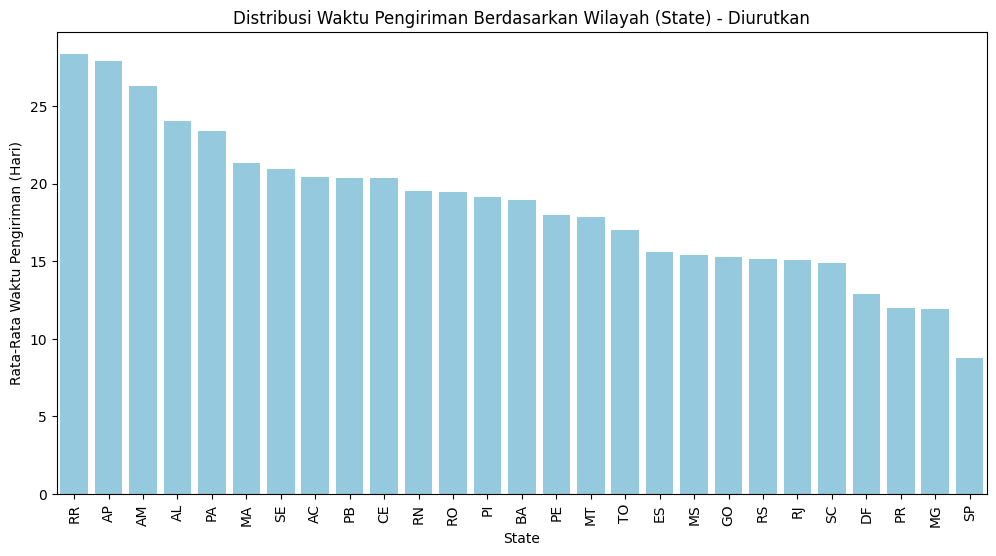

In [385]:
# Menghitung waktu pengiriman
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Menghitung rata-rata waktu pengiriman per state dan mengurutkannya
average_delivery_time = (
    df.groupby('customer_state')['delivery_time']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

colors_bar = ['#6a1b9a', '#ff5722', '#4caf50', '#2196f3']
# Visualisasi barplot 
plt.figure(figsize=(12, 6))
sns.barplot(data=average_delivery_time, x='customer_state', y='delivery_time', color='skyblue')
plt.title('Distribusi Waktu Pengiriman Berdasarkan Wilayah (State) - Diurutkan')
plt.xlabel('State')
plt.ylabel('Rata-Rata Waktu Pengiriman (Hari)')
plt.xticks(rotation=90)
plt.show()



Barplot diatas merupakan analisis yang dilakukan untuk melihat total waktu yang dibutuhkan dalam pengiriman pada masing-masing negara bagian. Data ini menunjukkan waktu rata-rata pengiriman untuk setiap negara bagian di Brasil, dengan São Paulo (SP) mencatatkan waktu pengiriman terpendek, yaitu 8.79 jam, diikuti oleh Minas Gerais (MG) dengan 11.91 jam dan Paraná (PR) dengan 11.98 jam. Sebaliknya, Roraima (RR) memiliki waktu pengiriman terpanjang, yaitu 28.35 jam, diikuti oleh Amapá (AP) dan Amazonas (AM) dengan waktu pengiriman masing-masing 27.90 jam dan 26.28 jam. Ini mengindikasikan adanya variasi besar dalam waktu pengiriman antar negara bagian.

Berdasarkan data ini, perusahaan dapat fokus untuk meningkatkan efisiensi pengiriman di negara bagian dengan waktu pengiriman lebih lama, seperti Roraima dan Amazonas, dengan meninjau rute pengiriman, meningkatkan logistik, atau mencari mitra pengiriman yang lebih efisien di wilayah tersebut. Di sisi lain, untuk negara bagian seperti São Paulo dan Minas Gerais, yang memiliki waktu pengiriman lebih cepat, perusahaan bisa memanfaatkan hal ini untuk meningkatkan kepuasan pelanggan melalui promosi atau layanan khusus yang memanfaatkan kecepatan pengiriman sebagai daya tarik.

### **2. Negara bagian yang paling banyak melakukan pemesanan**

customer_state
SP    49957
RJ    15416
MG    13734
RS     6521
PR     6017
SC     4327
BA     4071
DF     2489
GO     2443
ES     2347
PE     1894
CE     1560
MT     1129
PA     1122
MA      851
MS      849
PB      643
PI      574
RN      572
AL      460
SE      403
TO      340
RO      292
AM      172
AC       95
AP       84
RR       52
Name: count, dtype: int64


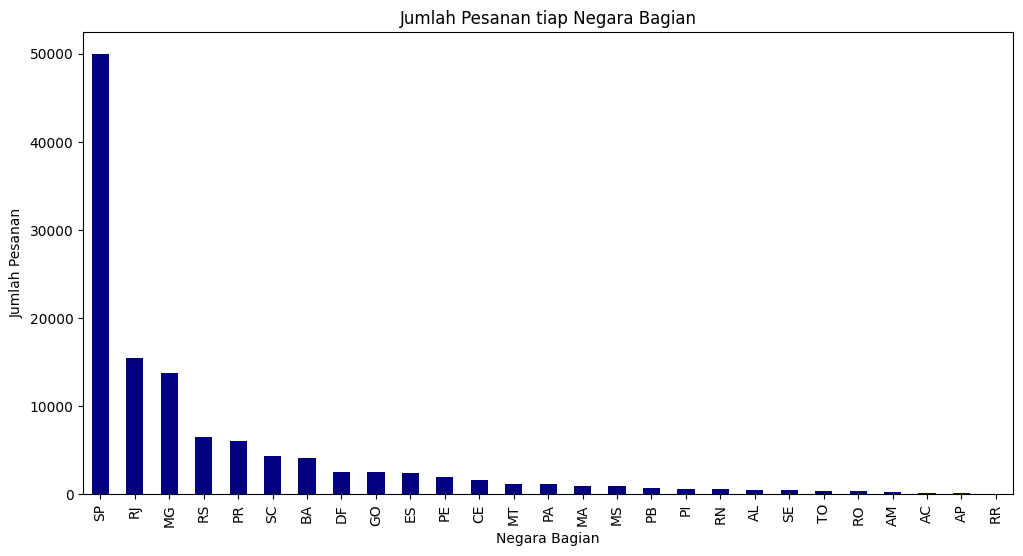

In [386]:
# Menghitung jumlah pesanan per state
state_orders = df['customer_state'].value_counts()
print(state_orders)
# Visualisasi
plt.figure(figsize=(12, 6))
state_orders.plot(kind='bar', color='navy')
plt.title('Jumlah Pesanan tiap Negara Bagian')
plt.xlabel('Negara Bagian')
plt.ylabel('Jumlah Pesanan')
plt.show()


Barplot diatas merupakan analisis negara bagian di brazil berdasrkan jumlah pemesanan yang dilakukan. Data ini menunjukkan negara bagian di Brasil yang paling banyak melakukan pemesanan, dengan São Paulo (SP) mencatatkan jumlah pemesanan tertinggi sebesar 49.967, diikuti oleh Rio de Janeiro (RJ) dengan 15.420 pesanan dan Minas Gerais (MG) dengan 13.738 pesanan. Negara bagian lain seperti Rio Grande do Sul (RS) dan Paraná (PR) juga menunjukkan angka pesanan yang cukup tinggi, sementara negara bagian seperti Acre (AC) dan Roraima (RR) mencatatkan jumlah pesanan yang sangat rendah, dengan hanya 95 dan 52 pesanan masing-masing.

Berdasarkan data ini, perusahaan dapat memfokuskan upaya pemasaran dan distribusi di negara bagian dengan volume pemesanan tinggi, seperti São Paulo dan Rio de Janeiro, dengan menawarkan penawaran khusus atau promosi untuk mempertahankan loyalitas pelanggan di wilayah tersebut. Di sisi lain, untuk negara bagian dengan pemesanan rendah seperti Acre dan Roraima, perusahaan dapat meningkatkan upaya pemasaran melalui kampanye lokal, menawarkan diskon atau insentif khusus, dan mengeksplorasi kemungkinan perbaikan dalam logistik untuk meningkatkan efisiensi pengiriman di wilayah-wilayah

### **3. Top 10 Kategori produk yang paling banyak dipesan**

product_category_name_english
bed_bath_table           11823
health_beauty             9975
sports_leisure            8945
furniture_decor           8744
computers_accessories     8082
housewares                7355
watches_gifts             6201
telephony                 4721
garden_tools              4574
auto                      4379
Name: count, dtype: int64


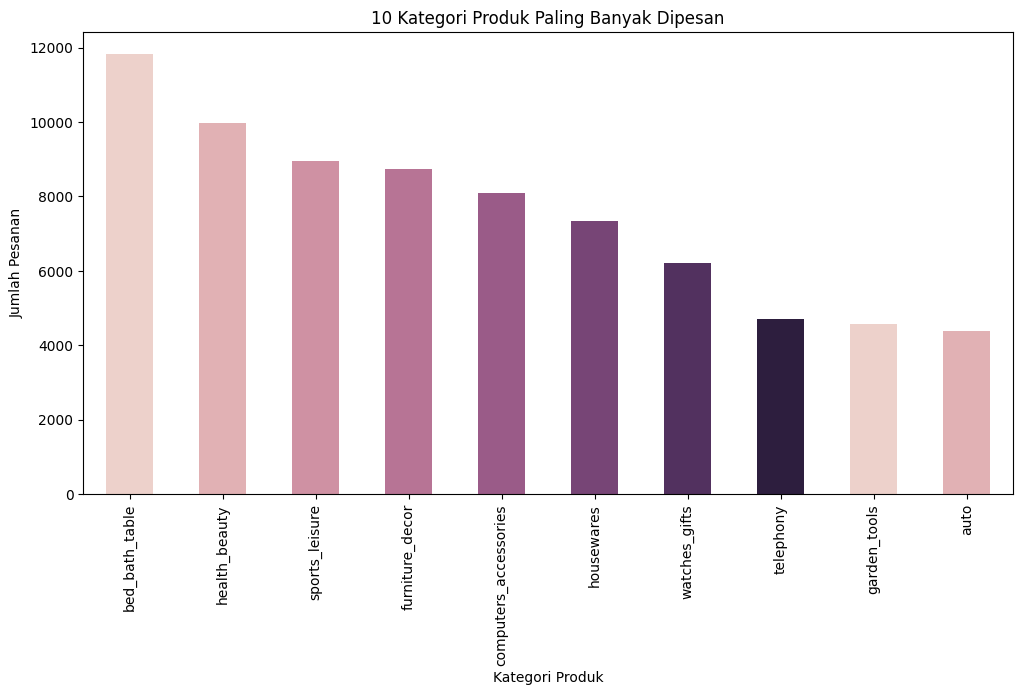

In [387]:
# Menghitung jumlah pesanan per kategori
category_orders = df['product_category_name_english'].value_counts()

# Menampilkan 20 kategori produk yang paling banyak dipesan
top_10_categories = category_orders.head(10)
print(top_10_categories)

# Visualisasi
plt.figure(figsize=(12, 6))
top_10_categories.plot(kind='bar', color=(sns.cubehelix_palette(8)))
plt.title('10 Kategori Produk Paling Banyak Dipesan')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=90)
plt.show()


Barplot diatas merupakan analisis terhadap banyaknya barang dipesan berdasarkan kategori. Data ini menunjukkan kategori produk yang paling banyak dipesan, dengan Bed, Bath & Table menduduki posisi teratas dengan 11.823 pesanan, diikuti oleh Health & Beauty (9.975) dan Sports & Leisure (8.945). Kategori Furniture & Decor dan Computers & Accessories juga mencatatkan angka pesanan yang signifikan. Di sisi lain, kategori Fashion Bags & Accessories dan Office Furniture mencatatkan pesanan lebih sedikit, dengan masing-masing 2.151 dan 1.778 pesanan.

Berdasarkan temuan ini, perusahaan dapat lebih fokus pada kategori dengan pesanan tinggi seperti Bed, Bath & Table, Health & Beauty, dan Sports & Leisure dengan menawarkan promosi atau memperkenalkan produk baru yang relevan. Untuk kategori dengan pesanan lebih rendah seperti Fashion Bags & Accessories dan Office Furniture, perusahaan bisa meningkatkan pemasaran dan penawaran produk untuk menarik lebih banyak pelanggan. Menangani kategori Unknown dengan cara memastikan pengolahan data pesanan yang lebih baik juga bisa meningkatkan keakuratan pelaporan dan strategi penjualan.

### **4. Top 10 Kategori produk dengan total revenue terbesar**

product_category_name_english
health_beauty            1486023.75
watches_gifts            1357478.82
bed_bath_table           1310284.13
sports_leisure           1198524.35
computers_accessories    1095456.98
furniture_decor           946593.12
housewares                820851.24
cool_stuff                750150.02
auto                      712442.08
garden_tools              623851.98
Name: sum, dtype: float64


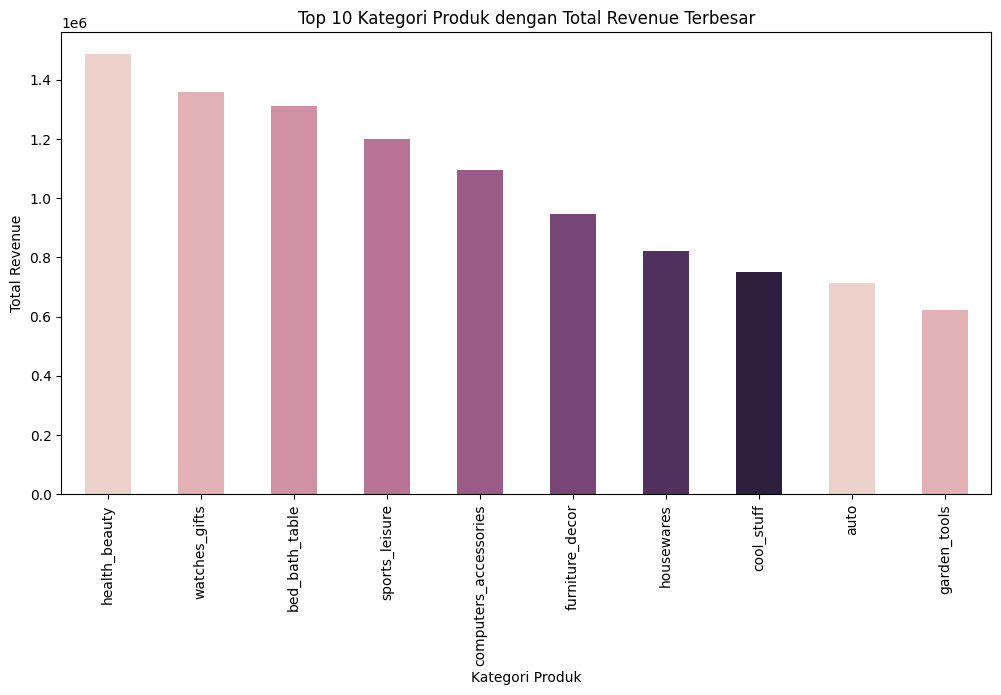

In [388]:
# Menghitung revenue
df['revenue'] = df['price'] + df['freight_value']
category_revenue = df.groupby('product_category_name_english')['revenue'].agg(['mean', 'sum'])

# Menampilkan 10 kategori produk dengan total revenue terbesar
top_10_category_revenue = category_revenue['sum'].sort_values(ascending=False).head(10)
print(top_10_category_revenue)
# Visualisasi
plt.figure(figsize=(12, 6))
top_10_category_revenue.plot(kind='bar', color=(sns.cubehelix_palette(8)))
plt.title('Top 10 Kategori Produk dengan Total Revenue Terbesar')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.show()


Barplot diatas merupakan analisis terhadap kategori dengan total revenue terbesar. Data menunjukkan bahwa kategori Health & Beauty menghasilkan total revenue tertinggi, mencapai 1.486.023, diikuti oleh Watches & Gifts dan Bed, Bath & Table. Kategori-kategori ini mencerminkan permintaan tinggi pada produk kesehatan, kecantikan, dan kebutuhan rumah tangga, sementara kategori seperti Sports & Leisure dan Computers & Accessories juga menunjukkan kontribusi signifikan, meskipun tidak setinggi dua kategori teratas. Di sisi lain, kategori Garden Tools menghasilkan pendapatan terendah dalam daftar.

Untuk memanfaatkan tren ini, perusahaan dapat fokus pada ekspansi dan promosi produk dalam kategori Health & Beauty dan Watches & Gifts, dengan menyesuaikan strategi pemasaran berdasarkan musim atau perayaan. Selain itu, penting untuk meningkatkan variasi produk di kategori Furniture & Decor dan Bed, Bath & Table, sementara kategori dengan pendapatan lebih rendah seperti Garden Tools dapat dioptimalkan dengan penawaran produk baru atau promosi untuk menarik pelanggan lebih banyak.

### **5. Kota yang memiliki waktu pengiriman tercepat dan terlama**

      customer_city  delivery_time
2745  paulino neves            2.0
1681         iomere            3.0
3742         siriji            3.0
2820           piao            3.0
3596   sao patricio            4.0


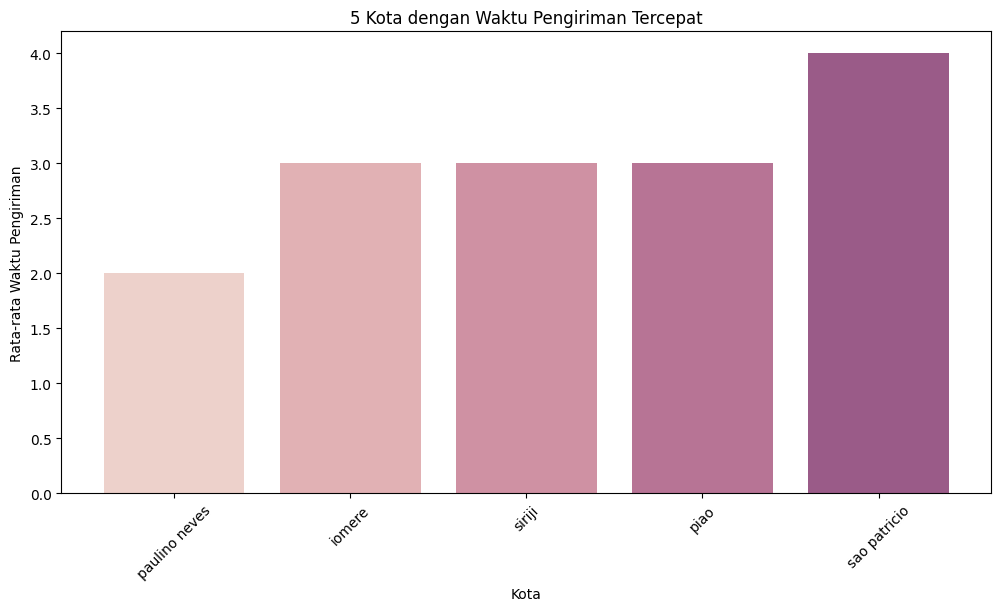

In [389]:
# Menghitung rata-rata waktu pengiriman per kota
delivery_by_city = df.groupby('customer_city')['delivery_time'].mean().reset_index()

# Menentukan kota dengan waktu pengiriman tercepat dan terlambat
fastest_delivery = delivery_by_city.sort_values(by='delivery_time').head(5)
slowest_delivery = delivery_by_city.sort_values(by='delivery_time', ascending=False).head(5)

print(fastest_delivery)
# Visualisasi untuk waktu pengiriman tercepat
plt.figure(figsize=(12, 6))
plt.bar(fastest_delivery['customer_city'], fastest_delivery['delivery_time'], color=(sns.cubehelix_palette(8)))
plt.title('5 Kota dengan Waktu Pengiriman Tercepat')
plt.xlabel('Kota')
plt.ylabel('Rata-rata Waktu Pengiriman')
plt.xticks(rotation=45)
plt.show()

Barplot diatas menunjukan analisis terhadap kota dengan waktu pengiriman tercepat. Kota dengan waktu pengiriman tercepat dalam data ini adalah Paulino Neves, dengan waktu pengiriman hanya 2 hari, yang merupakan waktu tercepat. Selain itu, kota seperti Piao dan Siriji memiliki waktu pengiriman selama 3 hari. Faktor-faktor yang mungkin memengaruhi kecepatan pengiriman ini meliputi kedekatan kota dengan gudang penjual, infrastruktur logistik yang lebih baik, atau efisiensi proses internal dari perusahaan logistik yang bertanggung jawab atas pengiriman. Sebagai rekomendasi, perusahaan dapat meniru strategi pengiriman yang diterapkan di kota-kota dengan waktu pengiriman tercepat ini dan mencoba mengimplementasikannya di wilayah lain yang memiliki waktu pengiriman lebih lama. 

            customer_city  delivery_time
2548          novo brasil     148.000000
797     capinzal do norte     109.000000
24      adhemar de barros      98.000000
3274  santa cruz de goias      86.666667
232                 arace      86.500000


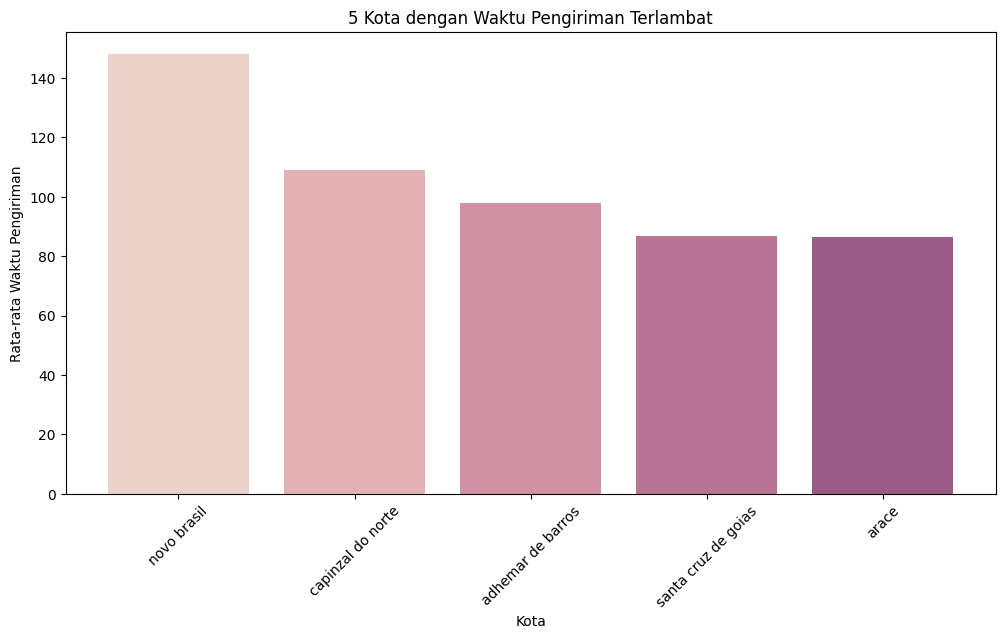

In [390]:
# Visualisasi untuk waktu pengiriman terlambat
print(slowest_delivery)

plt.figure(figsize=(12, 6))
plt.bar(slowest_delivery['customer_city'], slowest_delivery['delivery_time'], color=(sns.cubehelix_palette(8)))
plt.title('5 Kota dengan Waktu Pengiriman Terlambat')
plt.xlabel('Kota')
plt.ylabel('Rata-rata Waktu Pengiriman')
plt.xticks(rotation=45)
plt.show()

Barplot diatas menunjukan analisis terhadap kota dengan waktu pengiriman terlama. Berdasarkan data yang ada, beberapa kota dengan waktu pengiriman yang lebih lama adalah Novo Brasil dengan waktu pengiriman rata-rata 148 jam, diikuti oleh Capinzal do Norte dengan 109 jam, Adhemar de Barros dengan 98 jam, Santa Cruz de Goias dengan 86,67 jam, dan Arace dengan 86,5 jam. Kota-kota ini menunjukkan waktu pengiriman yang relatif lebih lama dibandingkan dengan daerah lain. 

Waktu pengiriman yang lebih lama di beberapa kota ini bisa disebabkan oleh berbagai faktor, seperti jarak yang lebih jauh dari pusat distribusi, keterbatasan infrastruktur transportasi, atau bahkan faktor logistik lainnya seperti kemacetan atau kekurangan armada pengiriman. Sebagai langkah perbaikan, perusahaan dapat mempertimbangkan untuk meningkatkan efisiensi pengiriman dengan mencari mitra logistik lokal yang lebih dekat atau mengoptimalkan rute pengiriman. 

### **6. Metode pembayaran yang palling sering digunakan**

payment_type
credit_card    73.712568
boleto         19.454625
voucher         5.394632
debit_card      1.433952
Unknown         0.004222
Name: proportion, dtype: float64


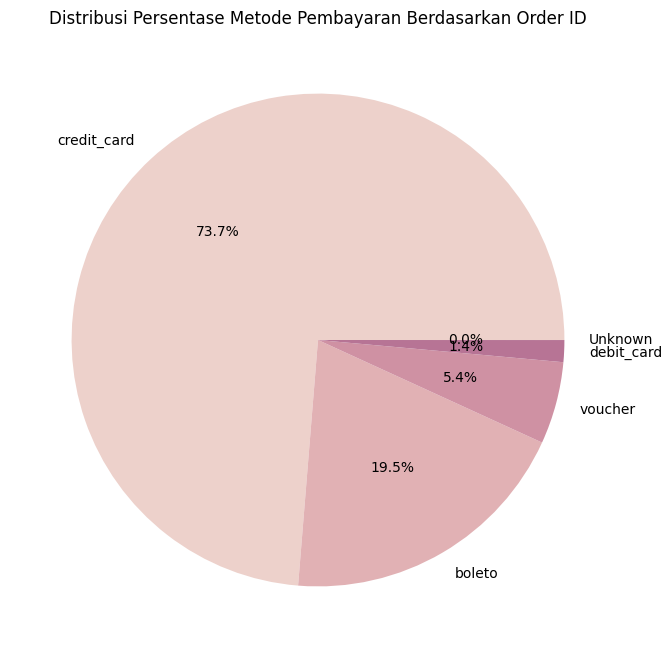

In [391]:
# Mengganti 'not_defined' dengan 'Unknown' pada kolom 'payment_type'
df['payment_type'] = df['payment_type'].replace('not_defined', 'Unknown')


# Menghitung metode pembayaran dan persentasenya
payment_types_percentage = df['payment_type'].value_counts(normalize=True) * 100

# Menampilkan persentase
print(payment_types_percentage)

# Visualisasi dalam pie chart
plt.figure(figsize=(8, 8))
plt.pie(payment_types_percentage, labels=payment_types_percentage.index, autopct='%1.1f%%', colors=(sns.cubehelix_palette(8)))
plt.title('Distribusi Persentase Metode Pembayaran Berdasarkan Order ID')
plt.show()

Analisis diatas merupakan analisis terhadap database pembayaran pelanggan dan jumlah pesanan menggunakan diagram lingkaran untuk mengidentifikasi metode pembayaran yang paling disukai. Berdasarkan diagram lingkaran, pelanggan menggunakan empat metode pembayaran utama: kartu kredit, Boleto, kartu debit, dan voucher. Dari semua pesanan, 73,7% pembayaran dilakukan menggunakan kartu kredit, diikuti oleh Boleto sebesar 19,5%. Voucher digunakan dalam 5,4% transaksi, kartu debit sebanyak 1,4%, dan hanya 0,005% pembayaran yang dikategorikan sebagai **Unknown**.

Mengingat mayoritas pembayaran dilakukan dengan kartu kredit, perusahaan dapat memperkuat kemitraan dengan penyedia kartu kredit untuk menawarkan promosi seperti cashback atau poin reward. Selain itu, metode pembayaran Boleto yang signifikan juga bisa dioptimalkan dengan memberikan diskon khusus atau perpanjangan waktu pembayaran.

In [392]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,payment_sequential,payment_type,payment_value,product_category_name_english,seller_city,seller_state,delivery_time,revenue
5325,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04,2016-10-07,2016-10-18,2016-11-09,2016-10-20,1.0,c1488892604e4ba5cff5b4eb4d595400,...,2.0,1400.0,1.0,credit_card,136.23,furniture_decor,monte siao,MG,66,71.66
5326,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04,2016-10-07,2016-10-18,2016-11-09,2016-10-20,2.0,f293394c72c9b5fafd7023301fc21fc2,...,3.0,1800.0,1.0,credit_card,136.23,furniture_decor,monte siao,MG,66,64.57
5164,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05,2016-10-07,2016-10-18,2016-11-09,2016-10-28,1.0,f3c2d01a84c947b078e32bbef0718962,...,1.0,700.0,1.0,credit_card,75.06,telephony,curitiba,PR,65,75.06
11923,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13,2016-10-07,2016-10-18,2016-11-09,2016-09-30,1.0,Unknown,...,1.0,700.0,1.0,credit_card,40.95,Unknown,Unknown,Unknown,57,91.19
36657,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15,2016-09-15,2016-11-07,2016-11-09,2016-10-04,1.0,5a6b04657a4c5ee34285d1e4619a96b4,...,1.0,1000.0,1.0,Unknown,108.20,health_beauty,curitiba,PR,55,47.82


In [393]:
total_data = df.shape
print(f"Total data: {total_data}")

Total data: (118414, 28)


In [394]:
# Save to a CSV file if necessary
df.to_csv(r"C:\DIBIMBING\olist_final_dataset.csv", index=False)